<a href="https://colab.research.google.com/github/ikoghoddds-bit/Data-Science-Portfolio-C21/blob/main/Projects/Project--1/Joseph_Project_1_To_Do_List.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 – To Do List



## Problem Definition

- The goal is to take customer information based on historical transaction records and predict whether or not a customer will make a transaction. This is a binary classification problem since the customer either makes a transaction, or doesn't. This project will use Naive Bayes Gaussian classification.


## Data Collection

1. Load Pandas, Numpy, and Matplotlib.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2. Load data Train.csv from AWS S3.

In [ ]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.1-Transactions/Data/Transaction.train.big.csv'

### Read dataframe into Pandas

In [ ]:
dataframe = pd.read_csv(url)
dataframe

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dataframe.head(5)

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
0,0,train_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,train_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,train_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,train_3,0.0,4.6739,22.3915,15.6015,NaN,0.0464,NaN,NaN,...,NaN,11.1077,NaN,-12.6465,NaN,NaN,NaN,NaN,NaN,14.0618
4,4,train_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dataframe.tail(5)

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,...,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,NaN,-6.3011,NaN,NaN,...,NaN,1.3921,NaN,-16.4925,NaN,NaN,NaN,NaN,NaN,14.4421
1049996,1049996,train_1049996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,NaN,3.5744,NaN,NaN,...,NaN,2.0836,NaN,-18.6168,NaN,NaN,NaN,NaN,NaN,14.0689
1049998,1049998,train_1049998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,NaN,8.1795,NaN,NaN,...,NaN,-12.1108,NaN,10.7608,NaN,NaN,NaN,NaN,NaN,14.1690


In [ ]:
dataframe.shape

(1050000, 104)

In [ ]:
print(dataframe.isnull().sum())

Unnamed: 0          0
ID_code             0
target         870000
var_0          870000
var_1          870000
               ...   
var_96        1050000
var_97        1050000
var_98        1050000
var_99        1050000
var_100        870000
Length: 104, dtype: int64


In [ ]:
dataframe['target'].value_counts()

,count
target,
0.0,161960
1.0,18040


In [ ]:
dataframe.duplicated().sum()

np.int64(0)

In [ ]:
print(dataframe.shape)

(1050000, 104)


In [ ]:
dataframe = dataframe[dataframe['target'].notna()]
print(dataframe.shape)

(180000, 104)


In [ ]:
print(dataframe.columns.tolist())

# dataframe = dataframe.drop(columns=['var_91', 'var_97', 'var_98', 'var_99']) this wipped all columns with nulls and data
print(dataframe.shape)

['Unnamed: 0', 'ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7', 'var_8', 'var_9', 'var_10', 'var_11', 'var_12', 'var_13', 'var_14', 'var_15', 'var_16', 'var_17', 'var_18', 'var_19', 'var_20', 'var_21', 'var_22', 'var_23', 'var_24', 'var_25', 'var_26', 'var_27', 'var_28', 'var_29', 'var_30', 'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_36', 'var_37', 'var_38', 'var_39', 'var_40', 'var_41', 'var_42', 'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_48', 'var_49', 'var_50', 'var_51', 'var_52', 'var_53', 'var_54', 'var_55', 'var_56', 'var_57', 'var_58', 'var_59', 'var_60', 'var_61', 'var_62', 'var_63', 'var_64', 'var_65', 'var_66', 'var_67', 'var_68', 'var_69', 'var_70', 'var_71', 'var_72', 'var_73', 'var_74', 'var_75', 'var_76', 'var_77', 'var_78', 'var_79', 'var_80', 'var_81', 'var_82', 'var_83', 'var_84', 'var_85', 'var_86', 'var_87', 'var_88', 'var_89', 'var_90', 'var_91', 'var_92', 'var_93', 'var_94', 'var_95', 'var_96', 'var

In [ ]:
print(dataframe.columns[dataframe.isnull().all()].tolist())


['var_3', 'var_5', 'var_6', 'var_9', 'var_10', 'var_11', 'var_12', 'var_13', 'var_16', 'var_18', 'var_19', 'var_23', 'var_25', 'var_30', 'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_40', 'var_42', 'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_50', 'var_51', 'var_53', 'var_54', 'var_55', 'var_58', 'var_59', 'var_60', 'var_64', 'var_68', 'var_69', 'var_71', 'var_74', 'var_76', 'var_77', 'var_79', 'var_81', 'var_90', 'var_91', 'var_93', 'var_95', 'var_96', 'var_97', 'var_98', 'var_99']


In [ ]:
print(dataframe.isnull().sum().sum())

9180000


In [ ]:
print(dataframe.isnull().sum()[dataframe.isnull().sum() > 0])


var_3     180000
var_5     180000
var_6     180000
var_9     180000
var_10    180000
var_11    180000
var_12    180000
var_13    180000
var_16    180000
var_18    180000
var_19    180000
var_23    180000
var_25    180000
var_30    180000
var_31    180000
var_32    180000
var_33    180000
var_34    180000
var_35    180000
var_40    180000
var_42    180000
var_43    180000
var_44    180000
var_45    180000
var_46    180000
var_47    180000
var_50    180000
var_51    180000
var_53    180000
var_54    180000
var_55    180000
var_58    180000
var_59    180000
var_60    180000
var_64    180000
var_68    180000
var_69    180000
var_71    180000
var_74    180000
var_76    180000
var_77    180000
var_79    180000
var_81    180000
var_90    180000
var_91    180000
var_93    180000
var_95    180000
var_96    180000
var_97    180000
var_98    180000
var_99    180000
dtype: int64


In [ ]:
null_cols = dataframe.columns[dataframe.isnull().all()].tolist()
dataframe = dataframe.drop(columns=null_cols)
print(f"Dropped {len(null_cols)} fully null columns")
print(dataframe.shape)


Dropped 51 fully null columns
(180000, 53)


In [ ]:
print(dataframe.isnull().sum().sum())
print(dataframe.duplicated().sum())

0
0


### Data Collection

### info()

In [ ]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180000 entries, 3 to 1049999
Data columns (total 53 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  180000 non-null  int64  
 1   ID_code     180000 non-null  object 
 2   target      180000 non-null  float64
 3   var_0       180000 non-null  float64
 4   var_1       180000 non-null  float64
 5   var_2       180000 non-null  float64
 6   var_4       180000 non-null  float64
 7   var_7       180000 non-null  float64
 8   var_8       180000 non-null  float64
 9   var_14      180000 non-null  float64
 10  var_15      180000 non-null  float64
 11  var_17      180000 non-null  float64
 12  var_20      180000 non-null  float64
 13  var_21      180000 non-null  float64
 14  var_22      180000 non-null  float64
 15  var_24      180000 non-null  float64
 16  var_26      180000 non-null  float64
 17  var_27      180000 non-null  float64
 18  var_28      180000 non-null  float64
 19  var_29

### describe()

In [ ]:
dataframe.describe()

,Unnamed: 0,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,var_15,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
count,1.800000e+05,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,...,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000
mean,5.259073e+05,0.100222,7.440715,15.870166,12.735619,-0.668334,1.190419,6.813431,11.946357,2.963064,...,11.434945,3.990847,7.566953,12.756574,10.342814,1.927078,-0.746871,-3.294620,-6.727860,14.224538
std,3.031568e+05,0.300297,3.021636,3.010492,4.185923,5.968300,5.169343,0.375564,7.364523,0.369891,...,0.541385,0.198989,1.235043,9.320939,2.520602,1.476777,1.862151,7.418545,8.278554,0.171058
min,3.000000e+00,0.000000,-2.691700,6.299300,-1.018500,-22.748700,-15.194000,5.359300,-19.544300,1.851200,...,9.816900,3.320500,3.970500,-18.489700,0.427400,-3.814500,-7.280600,-29.984000,-35.211700,13.729000
25%,2.632305e+05,0.000000,5.160325,13.830400,9.664675,-4.997500,-2.571400,6.544100,6.756875,2.698400,...,11.032400,3.853700,6.618800,5.661300,8.646700,0.890000,-2.105300,-8.757925,-12.835875,14.098900
50%,5.269195e+05,0.000000,7.350950,15.934600,12.670700,-0.560300,1.194600,6.806800,11.925300,2.959900,...,11.435500,3.996000,7.628500,12.520300,10.395800,1.899700,-0.772000,-3.170950,-6.615100,14.226800
75%,7.881872e+05,0.000000,9.511125,18.061425,15.837300,3.632525,5.090450,7.070900,17.039600,3.241425,...,11.845000,4.131625,8.583800,19.461725,12.116300,2.947225,0.526925,2.043350,-0.885250,14.361800
max,1.049999e+06,1.000000,16.716500,26.079100,26.997600,18.855400,18.471400,8.309100,39.396800,4.220400,...,13.287800,4.752800,11.150600,44.363400,20.437300,8.402400,4.993900,21.236400,18.105600,14.743000


### head()

In [ ]:
dataframe.head()

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275


### tail()

In [ ]:
dataframe.tail()

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689
1049999,1049999,train_1049999,0.0,2.1828,12.3805,17.5654,8.1795,-5.5755,6.3705,5.1813,...,12.0632,3.8415,6.3466,30.6304,10.7439,-0.1808,0.2578,-12.1108,10.7608,14.1690


### target value_counts()

In [ ]:
dataframe["target"].value_counts()

,count
target,
0.0,161960
1.0,18040


In [ ]:
dataframe["target"].value_counts(dropna = False)

,count
target,
0.0,161960
1.0,18040


***"target" contains, 0s, 1s and 870000 NaNs***

### isnull()/isna()

In [ ]:
dataframe.isnull().sum()*100

,0
Unnamed: 0,0
ID_code,0
target,0
var_0,0
var_1,0
var_2,0
var_4,0
var_7,0
var_8,0
var_14,0


In [ ]:
dataframe.isna().sum().sort_values()

,0
Unnamed: 0,0
ID_code,0
target,0
var_0,0
var_1,0
var_2,0
var_4,0
var_7,0
var_8,0
var_14,0


### shape

In [ ]:
dataframe.shape

(180000, 53)

### size

In [ ]:
dataframe.size

9540000

### nunique()

In [ ]:
nunique = dataframe.nunique().sort_values(ascending = False)
nunique

,0
Unnamed: 0,180000
ID_code,180000
var_52,137280
var_86,134537
var_94,131746
var_20,130573
var_48,130208
var_65,129702
var_78,129453
var_92,128142


### unique()

In [ ]:
dataframe['target'].unique()

array([0., 1.])

### Backup - ***Making a backup***

In [ ]:
dataframe_bak01 = dataframe.copy()
dataframe_bak01

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


## Data Cleaning

4. Examine the data using tools we have used in class.

### Scanning dataframe and dropping all "nulls" in the dataframe

In [ ]:
dataframe_bak01.columns.to_list()

['Unnamed: 0',
 'ID_code',
 'target',
 'var_0',
 'var_1',
 'var_2',
 'var_4',
 'var_7',
 'var_8',
 'var_14',
 'var_15',
 'var_17',
 'var_20',
 'var_21',
 'var_22',
 'var_24',
 'var_26',
 'var_27',
 'var_28',
 'var_29',
 'var_36',
 'var_37',
 'var_38',
 'var_39',
 'var_41',
 'var_48',
 'var_49',
 'var_52',
 'var_56',
 'var_57',
 'var_61',
 'var_62',
 'var_63',
 'var_65',
 'var_66',
 'var_67',
 'var_70',
 'var_72',
 'var_73',
 'var_75',
 'var_78',
 'var_80',
 'var_82',
 'var_83',
 'var_84',
 'var_85',
 'var_86',
 'var_87',
 'var_88',
 'var_89',
 'var_92',
 'var_94',
 'var_100']

In [ ]:
dataframe_bak01.columns

Index(['Unnamed: 0', 'ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_4',
       'var_7', 'var_8', 'var_14', 'var_15', 'var_17', 'var_20', 'var_21',
       'var_22', 'var_24', 'var_26', 'var_27', 'var_28', 'var_29', 'var_36',
       'var_37', 'var_38', 'var_39', 'var_41', 'var_48', 'var_49', 'var_52',
       'var_56', 'var_57', 'var_61', 'var_62', 'var_63', 'var_65', 'var_66',
       'var_67', 'var_70', 'var_72', 'var_73', 'var_75', 'var_78', 'var_80',
       'var_82', 'var_83', 'var_84', 'var_85', 'var_86', 'var_87', 'var_88',
       'var_89', 'var_92', 'var_94', 'var_100'],
      dtype='object')

### Scanning dataframe and dropping "nulls" in specified columns and deleting those rows

In [ ]:
dataframe_bak01.dropna(subset = ['target'])

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


### Working from Backup file now to actually drop "nulls"in the dataset.

In [ ]:
dataframe_bak01.dropna(subset = ['target'], inplace = True)
dataframe_bak01

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [ ]:
dataframe_bak01.shape

(180000, 53)

In [ ]:
dataframe_bak01.isnull().sum()*1000

,0
Unnamed: 0,0
ID_code,0
target,0
var_0,0
var_1,0
var_2,0
var_4,0
var_7,0
var_8,0
var_14,0


In [ ]:
dataframe_bak01.isnull().sum().sort_values()

,0
Unnamed: 0,0
ID_code,0
target,0
var_0,0
var_1,0
var_2,0
var_4,0
var_7,0
var_8,0
var_14,0


In [ ]:
dataframe_bak01.shape

(180000, 53)

In [ ]:
dataframe_bak01.dropna(axis='columns')

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [ ]:
dataframe_bak01.shape

(180000, 53)

In [ ]:
dataframe_bak01.dropna(axis='columns', how = 'all')

,Unnamed: 0,ID_code,target,var_0,var_1,var_2,var_4,var_7,var_8,var_14,...,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_92,var_94,var_100
3,3,train_3,0.0,4.6739,22.3915,15.6015,0.0464,-1.9254,6.4760,21.6435,...,11.8011,3.9677,9.5382,-8.4394,5.5043,2.2732,1.6362,11.1077,-12.6465,14.0618
5,5,train_5,0.0,14.6962,18.3383,17.4788,-9.1355,-6.4882,6.0821,11.7476,...,11.8294,3.8887,8.8591,6.1482,8.5833,2.8432,1.8434,-2.0111,-3.6166,14.4520
11,11,train_11,0.0,4.4949,14.4142,13.2219,4.9140,4.0501,5.8144,18.7136,...,11.7464,4.0017,5.8179,10.4951,12.4494,2.8009,0.3394,13.9424,-15.5776,14.1222
15,15,train_15,0.0,4.9657,16.2867,17.9579,0.6017,-5.4904,6.6670,8.1019,...,11.5481,3.9809,8.2247,21.2257,6.9931,3.3939,-2.3905,3.7943,5.6184,14.0619
19,19,train_19,0.0,9.4287,18.7822,10.7630,-0.7532,8.8477,6.8045,19.0069,...,10.8981,4.1808,9.4220,1.8563,10.5738,1.2409,-1.3888,-5.6677,-1.8961,14.0275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049990,1049990,train_1049990,0.0,7.9632,20.4650,10.7295,2.9322,5.0267,7.1953,10.0695,...,12.1000,4.2019,7.1249,14.6591,10.2705,3.5833,2.5588,10.4219,-19.7158,14.0582
1049993,1049993,train_1049993,0.0,5.0862,14.4785,17.3709,-2.4732,-2.5987,6.6798,3.0420,...,10.9960,3.9637,8.0217,11.0449,9.3100,1.0545,-2.8770,-2.8052,-13.7290,14.3794
1049995,1049995,train_1049995,1.0,11.3251,16.4148,20.5955,-6.3011,-6.8112,7.3226,14.9182,...,11.2265,3.8431,8.2748,-7.8464,9.9774,1.7377,-1.7942,1.3921,-16.4925,14.4421
1049997,1049997,train_1049997,0.0,8.9941,13.4127,3.9567,3.5744,1.6614,6.1486,12.0996,...,10.5067,4.0642,8.3381,17.9081,12.3357,2.6530,-1.2359,2.0836,-18.6168,14.0689


In [ ]:
dataframe_bak01.dropna(axis='columns', how = 'all', inplace = True)

In [ ]:
dataframe_bak01.shape

(180000, 53)

Size

In [ ]:
dataframe_bak01.size

9540000

5. If there are data cleaning issues, develop recommendations for how to deal with them.

## Exploratory Data Analysis






6. Produce some visual analysis of the data – like plots showing the distributions of all variables. Recall that Gaussian Naive Bayes assumes the predictors are normally distributed. Note: you might have to do multiple plots in groups.

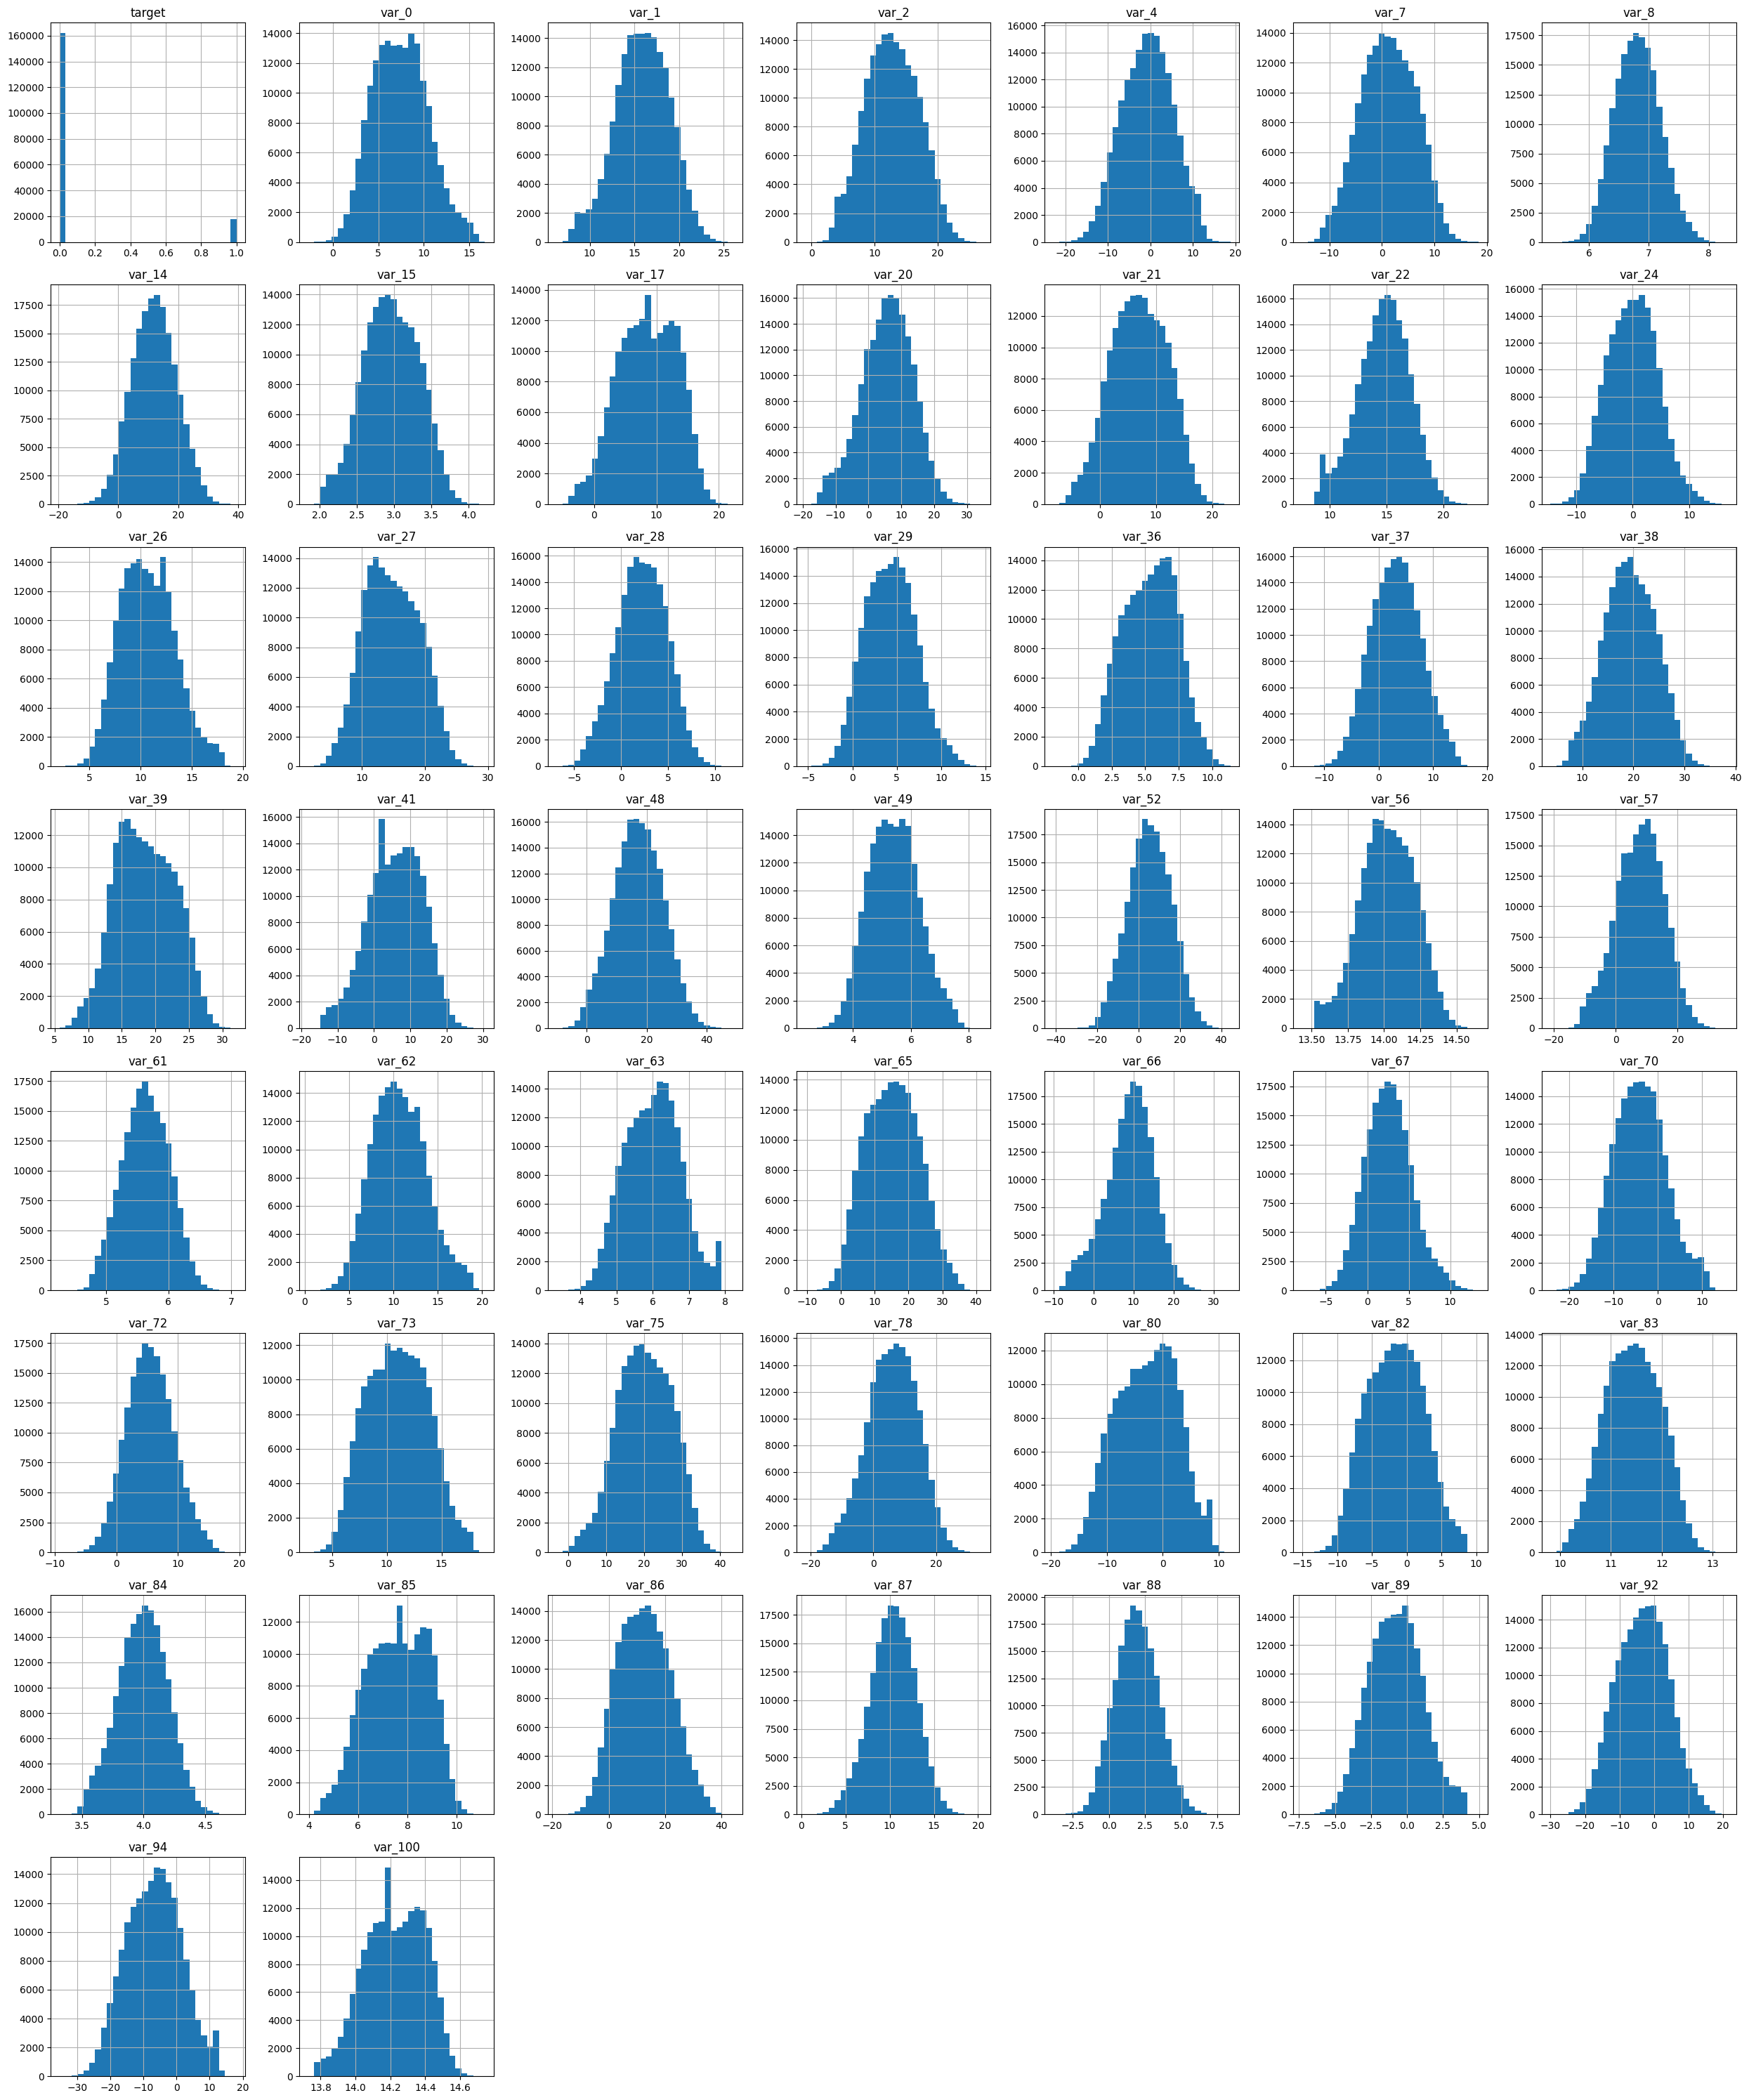

In [ ]:
predictors = dataframe.drop(columns=['Unnamed: 0', 'ID_code'])
predictors.hist(figsize=(25, 30), bins=30)
plt.tight_layout()
plt.show()

7. NOTE: the ‘target’ column indicates a successful transaction (‘1’) or a no-transaction (‘0’). Verify these are the only values in that column.

In [ ]:
dataframe['target'].isnull().sum()

np.int64(0)

8. Check the correlation values between all predictor columns to ensure there are no substantial correlations between predictors. This is important to support the decision to classify the ‘target’ using Naïve Bayes.

In [ ]:
dataframe_transaction = dataframe[dataframe['target'] == 1.0].copy()
dataframe_non_transaction = dataframe[dataframe['target'] == 0.0].copy()
print(dataframe_transaction.shape)
print(dataframe_non_transaction.shape)

(18040, 53)
(161960, 53)


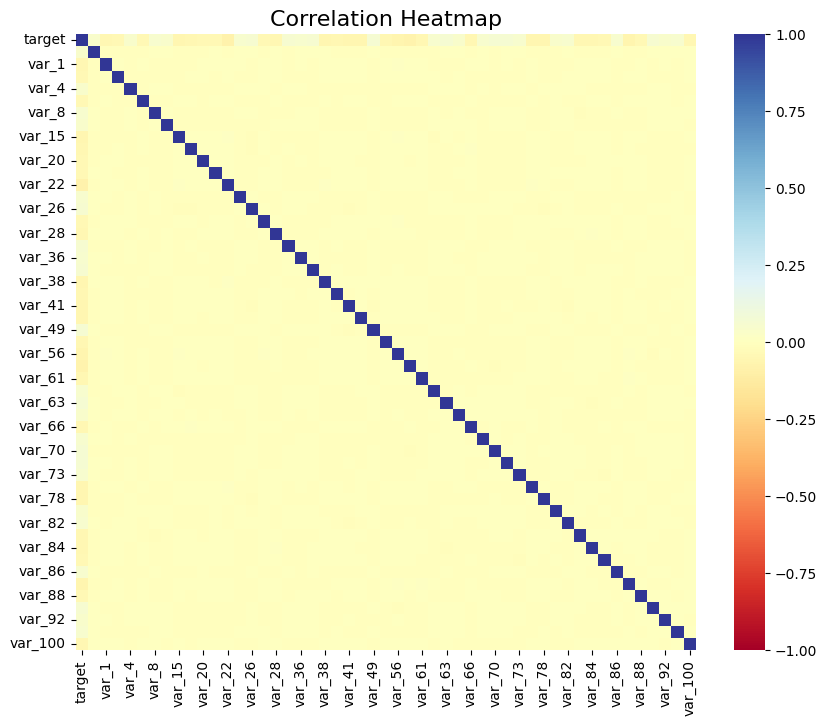

In [ ]:
# Drop 'Unnamed: 0' so it doesn't clutter your heatmap
corr_clean = dataframe.drop(columns=['Unnamed: 0']).corr(numeric_only=True)

# Plot the clean heatmap without overlapping text numbers
plt.figure(figsize=(10, 8))  # Increased size to give labels breathing room
sns.heatmap(corr_clean, cmap='RdYlBu', annot=False, vmin=-1, vmax=1)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [ ]:
features = dataframe_bak01.drop(columns=['target']).copy()
target = dataframe_bak01['target'].copy()

print(features.shape)
print(target.shape)

(180000, 52)
(180000,)



11. Define a Gaussian Naïve Bayes model using Sklearn.



In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
print(model)

GaussianNB()


12. Divide the two data frames you created in step #10 into training and testing subsets.


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(144000, 50)
(36000, 50)


13. Train the model using the training subset of the dataset.


In [ ]:
model.fit(X_train, y_train)

GaussianNB()

14. Test the model using the testing subset of the dataset. Calculate and report the accuracy.


In [ ]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9109166666666667


15. Perform a cross-validation loop to calculate the accuracy of your model. Report that accuracy. How does it compare to the accuracy you calculated in #14?


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
print(f"Cross-validation scores: {scores}")
print(f"Mean accuracy: {scores.mean()}")

Cross-validation scores: [0.91066667 0.91186111 0.91038889 0.91119444 0.91252778]
Mean accuracy: 0.9113277777777778


16. Plot a histogram of the accuracy scores you generated in your cross-validation loop. What do you notice about the distribution of accuracy scores?


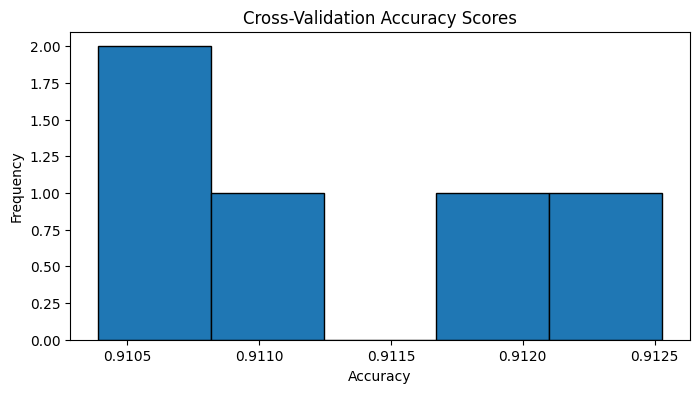

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(scores, bins=5, edgecolor='black')
plt.title('Cross-Validation Accuracy Scores')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.show()

17.  Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report). What do you notice?



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[31983   419]
 [ 2788   810]]
              precision    recall  f1-score   support

         0.0       0.92      0.99      0.95     32402
         1.0       0.66      0.23      0.34      3598

    accuracy                           0.91     36000
   macro avg       0.79      0.61      0.64     36000
weighted avg       0.89      0.91      0.89     36000



18. The training data is very skewed towards non-successful transactions (about 90% of the training data has ‘target’==0). Remove enough non-successful transaction rows so that your remaining training data is 50%/50% split between successful and non-successful transactions. Hint: you can use the data frames you created in step #9.


In [ ]:
dataframe_balanced = pd.concat([
    dataframe_transaction,
    dataframe_non_transaction.sample(n=len(dataframe_transaction), random_state=42)
])
print(dataframe_balanced['target'].value_counts())
print(dataframe_balanced.shape)

target
1.0    18040
0.0    18040
Name: count, dtype: int64
(36080, 53)


In [ ]:
X_bal = dataframe_balanced.drop(columns=['Unnamed: 0', 'ID_code', 'target']).copy()
y_bal = dataframe_balanced['target'].copy()
scores_bal = cross_val_score(model, X_bal, y_bal, cv=5)
print(f"Balanced CV scores: {scores_bal}")
print(f"Balanced mean accuracy: {scores_bal.mean()}")

Balanced CV scores: [0.75207871 0.75970067 0.74833703 0.75207871 0.75817627]
Balanced mean accuracy: 0.7540742793791574


20. Repeat the cross-validation process on this data set. Report what your cross-validation accuracy is in this 50/50 case.

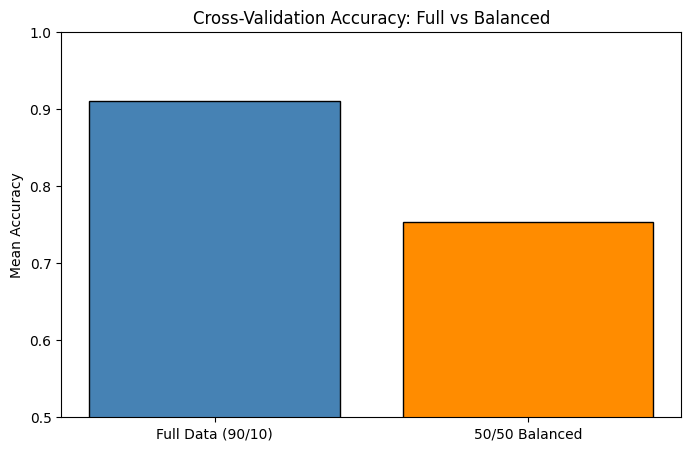

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(['Full Data (90/10)', '50/50 Balanced'],
        [scores.mean(), scores_bal.mean()],
        color=['steelblue', 'darkorange'],
        edgecolor='black')
plt.title('Cross-Validation Accuracy: Full vs Balanced')
plt.ylabel('Mean Accuracy')
plt.ylim(0.5, 1.0)
plt.show()

## Data Visualization


20. Compare the results of your cross-validation with the whole training data and the reduced 50/50 training data



In [ ]:
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42)
model.fit(X_train_bal, y_train_bal)
y_pred_bal = model.predict(X_test_bal)

print(confusion_matrix(y_test_bal, y_pred_bal))
print(classification_report(y_test_bal, y_pred_bal))

[[2759  845]
 [ 917 2695]]
              precision    recall  f1-score   support

         0.0       0.75      0.77      0.76      3604
         1.0       0.76      0.75      0.75      3612

    accuracy                           0.76      7216
   macro avg       0.76      0.76      0.76      7216
weighted avg       0.76      0.76      0.76      7216



21. Present the confusion matrix and the results of your Classification Report (sklearn.metrics.classification_report)


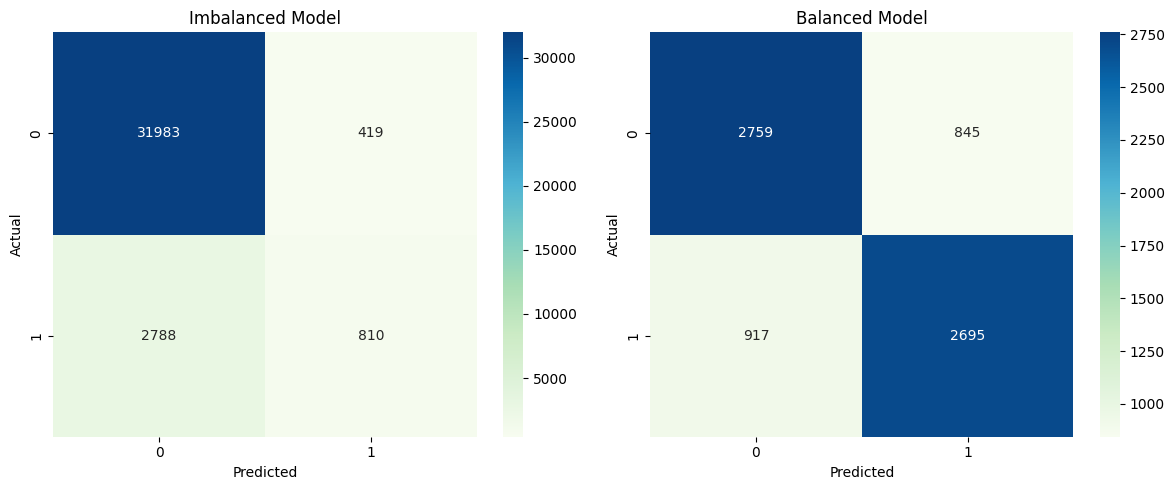

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Imbalanced model confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Balanced model confusion matrix
cm_bal = confusion_matrix(y_test_bal, y_pred_bal)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu', ax=axes[0])
axes[0].set_title('Imbalanced Model')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='GnBu', ax=axes[1])
axes[1].set_title('Balanced Model')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

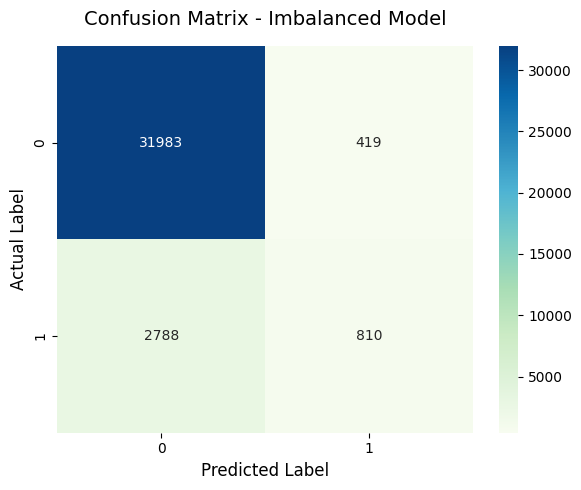

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute matrix for the imbalanced data
cm = confusion_matrix(y_test, y_pred)

# Set up a standalone figure
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu')

# Add labels and title
plt.title('Confusion Matrix - Imbalanced Model', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

plt.tight_layout()
plt.show()

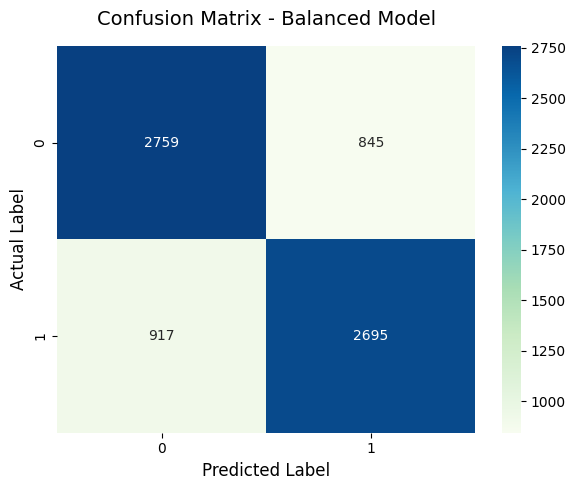

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute matrix for the balanced data
cm_bal = confusion_matrix(y_test_bal, y_pred_bal)

# Set up a standalone figure
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='GnBu')

# Add labels and title
plt.title('Confusion Matrix - Balanced Model', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

plt.tight_layout()
plt.show()

## Communicate the Results



22. Communicate the results of your analysis.

### Key Findings

- My raw model showed a misleading 91.1% accuracy because 90% of the dataset consists of non-buyers. A useless model that simply guesses "nobody buys" would score 90% accuracy without finding a single customer.

- When evaluated using a confusion matrix, the imbalanced model completely missed 2,788 out of 3,598 actual buyers (False Negatives), making it commercially unviable.

- Forcing a 50/50 balanced dataset dropped overall accuracy to 75.4% but completely repaired the model's predictive utility.

- By training on balanced data, the model successfully flagged 2,695 true buyers, dramatically reducing missed revenue opportunities.


- ***Statistical Blueprint Validated: Before modeling, my grid of feature histograms confirmed healthy Gaussian distributions, and my heatmap proved absolute feature independence, completely validating our algorithm choice.***

### Recommendation

- Deploy the Balanced Gaussian Naive Bayes Model. In a customer transaction pipeline, a False Negative (missing a real customer who wanted to buy) is far more expensive than a False Positive (marketing to someone who doesn't buy). While the balanced model has a lower headline accuracy score, it is the superior business tool because it actively catches actual revenue.

- Next Steps: For future iterations, use this 75.4% balanced baseline to test more advanced ensemble models like XGBoost or Random Forest to push predictive accuracy past the 80% mark.

## Submit Final Project

23. Upload your finished Jupyter notebook to your Project 1 student folder.
